# HW 1 - exactly the same architectures (both densely connected layers and from convolutional layers)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from datetime import datetime

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
%matplotlib inline

from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F

from PIL import Image


In [2]:
from torchvision.datasets import FashionMNIST

mnist_dataset = FashionMNIST(root = 'data/', download=True, train = True, transform = transforms.ToTensor())
print(mnist_dataset)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()


torch.Size([1, 28, 28]) 0
tensor([[[0.6510, 0.5961, 0.6196, 0.6196, 0.6275],
         [0.6235, 0.6000, 0.6157, 0.6196, 0.6353],
         [0.6196, 0.6078, 0.6353, 0.6196, 0.6275],
         [0.5961, 0.6275, 0.6196, 0.6314, 0.6275],
         [0.5765, 0.6431, 0.6078, 0.6471, 0.6314]]])
tensor(1.) tensor(0.)


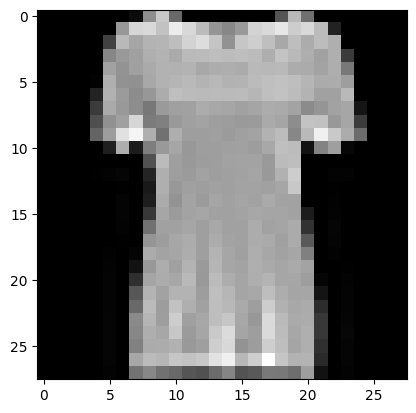

In [3]:
sampleTensor, label = mnist_dataset[10]
print(sampleTensor.shape, label)
tpil = transforms.ToPILImage() # using the __call__ to
image = tpil(sampleTensor)
image.show()

print(sampleTensor[:,10:15,10:15])
print(torch.max(sampleTensor), torch.min(sampleTensor))
plt.imshow(sampleTensor[0,:,:],cmap = 'gray')

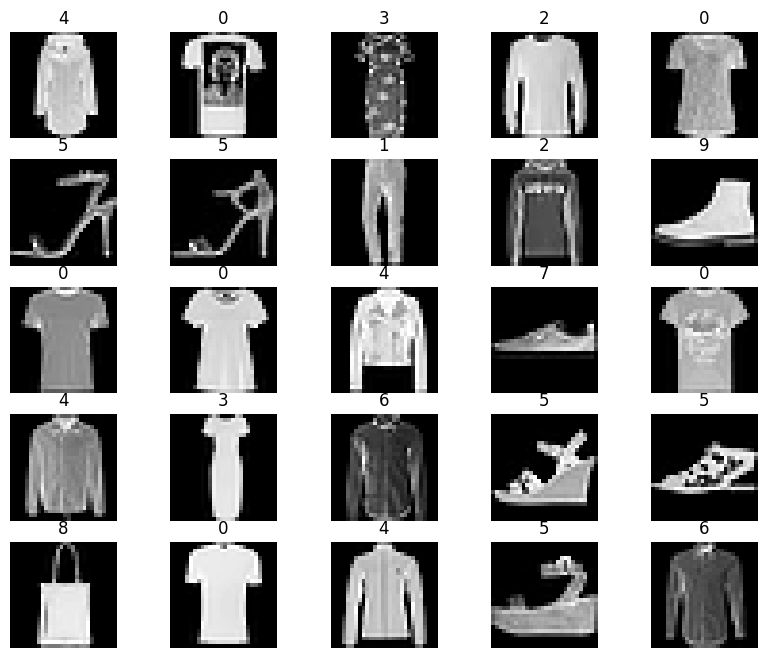

In [4]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(mnist_dataset), size=(1,)).item()
    img, label = mnist_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

tensor([[[0.6510, 0.5961, 0.6196, 0.6196, 0.6275],
         [0.6235, 0.6000, 0.6157, 0.6196, 0.6353],
         [0.6196, 0.6078, 0.6353, 0.6196, 0.6275],
         [0.5961, 0.6275, 0.6196, 0.6314, 0.6275],
         [0.5765, 0.6431, 0.6078, 0.6471, 0.6314]]])
tensor(1.) tensor(0.)


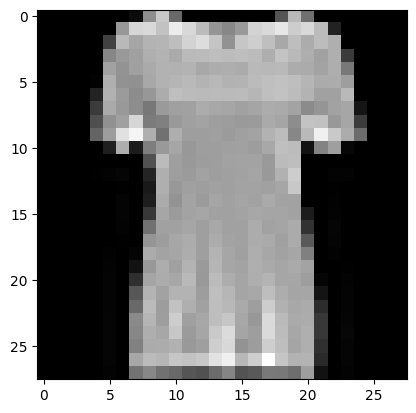

In [5]:
print(sampleTensor[:,10:15,10:15])
print(torch.max(sampleTensor), torch.min(sampleTensor))
plt.imshow(sampleTensor[0,:,:],cmap = 'gray')

In [6]:
train_data, validation_data = random_split(mnist_dataset, [50000, 10000])
print("length of Train Datasets: ", len(train_data))
print("length of Validation Datasets: ", len(validation_data))

batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(validation_data, batch_size, shuffle = False)

length of Train Datasets:  50000
length of Validation Datasets:  10000


In [7]:
input_size = 28 * 28
num_classes = 10

model = nn.Linear(input_size, num_classes)

In [8]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        print(xb)
        out = self.linear(xb)
        print(out)
        return(out)

model = MnistModel()
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[-0.0177, -0.0280,  0.0098,  ..., -0.0325,  0.0168, -0.0099],
         [-0.0017,  0.0184, -0.0106,  ..., -0.0125,  0.0148, -0.0326],
         [ 0.0221, -0.0059, -0.0107,  ...,  0.0006, -0.0215, -0.0243],
         ...,
         [-0.0048,  0.0353,  0.0081,  ..., -0.0193, -0.0087,  0.0283],
         [ 0.0265, -0.0117,  0.0132,  ..., -0.0253,  0.0259, -0.0209],
         [ 0.0147, -0.0243, -0.0119,  ...,  0.0324,  0.0273, -0.0112]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0230, -0.0333,  0.0238,  0.0119,  0.0073, -0.0027, -0.0275,  0.0098,
         -0.0197, -0.0037], requires_grad=True)]

In [9]:
for images, labels in train_loader:
    outputs = model(images)
    break

print('Outputs shape: ', outputs.shape)
print('Sample outputs: \n', outputs[:2].data)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[-0.1273,  0.0275,  0.1365,  ..., -0.0982, -0.2498, -0.0856],
        [ 0.1606, -0.0237,  0.1612,  ...,  0.0922, -0.0013, -0.0840],
        [-0.0141, -0.3023,  0.0601,  ...,  0.1287, -0.5040, -0.1109],
        ...,
        [ 0.0275, -0.3228,  0.3347,  ...,  0.0105,  0.0433, -0.1778],
        [ 0.2913, -0.1234,  0.2973,  ..., -0.0126, -0.1158, -0.0634],
        [ 0.0406, -0.2540,  0.2791,  ..., -0.1001, -0.0731,  0.0807]],
       grad_fn=<AddmmBackward0>)
Outputs shape:  torch.Size([128, 10])
Sample outputs: 
 tensor([[-0.1273,  0.0275,  0.1365, -0.0077, -0.1806, -0.1474,  0.1165, -0.0982,
         -0.2498, -0.0856],
        [ 0.1606, -0.0237,  0.1612, -0.0100,  0.2824, -0.3350,  0.1681,  0.0922,
         -0.0013, -0.0840]])


In [10]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim = 1)
    return(torch.tensor(torch.sum(preds == labels).item()/ len(preds)))

print("Accuracy: ", accuracy(outputs, labels))
print("\n")
loss_fn = F.cross_entropy
print("Loss Function: ",loss_fn)
print("\n")
loss = loss_fn(outputs, labels)
print(loss)


Accuracy:  tensor(0.1172)


Loss Function:  <function cross_entropy at 0x7a68c846dd00>


tensor(2.3374, grad_fn=<NllLossBackward0>)


In [11]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return(out)

    def training_step(self, batch):

        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return(loss)

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return({'val_loss':loss, 'val_acc': acc})

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return({'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()})

    def epoch_end(self, epoch,result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

model = MnistModel()

def evaluate(model, data_loader):
    outputs = [model.validation_step(batch) for batch in data_loader]
    return(model.validation_epoch_end(outputs))

def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return(history)

In [12]:
result0 = evaluate(model, val_loader)
result0

{'val_loss': 2.3955366611480713, 'val_acc': 0.10413370281457901}

In [13]:
history1 = fit(10, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.7413, val_acc: 0.6258
Epoch [1], val_loss: 1.4331, val_acc: 0.6647
Epoch [2], val_loss: 1.2587, val_acc: 0.6764
Epoch [3], val_loss: 1.1474, val_acc: 0.6853
Epoch [4], val_loss: 1.0704, val_acc: 0.6929
Epoch [5], val_loss: 1.0135, val_acc: 0.6985
Epoch [6], val_loss: 0.9694, val_acc: 0.7064
Epoch [7], val_loss: 0.9343, val_acc: 0.7153
Epoch [8], val_loss: 0.9049, val_acc: 0.7227
Epoch [9], val_loss: 0.8805, val_acc: 0.7290


Text(0.5, 1.0, 'Accuracy over epochs')

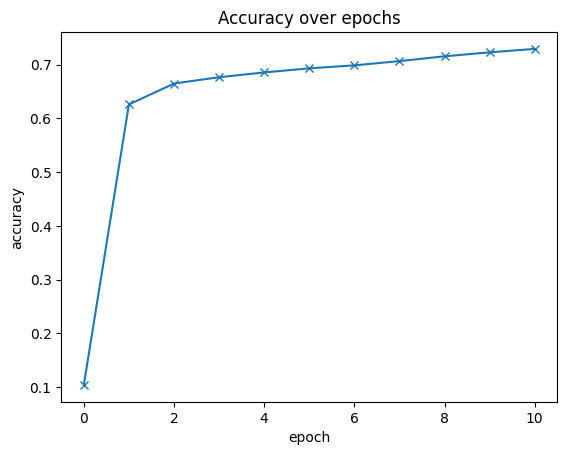

In [14]:
history = [result0] + history1
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy over epochs')

Text(0.5, 1.0, 'Losses  over epochs')

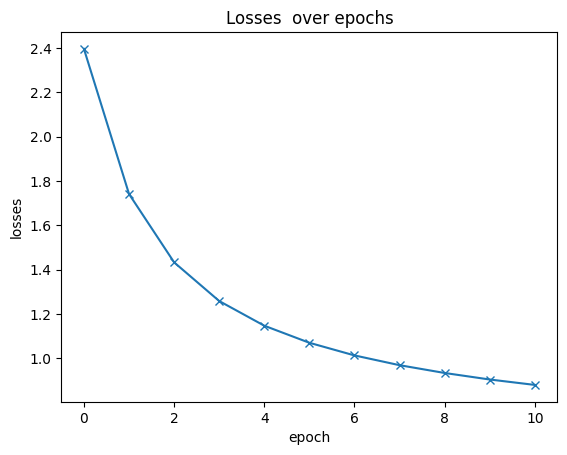

In [15]:
history = [result0] + history1
losses = [result['val_loss'] for result in history]
plt.plot(losses, '-x')
plt.xlabel('epoch')
plt.ylabel('losses')
plt.title('Losses  over epochs')

Length of Test Datasets:  10000
Shape:  torch.Size([1, 28, 28])
Label:  9


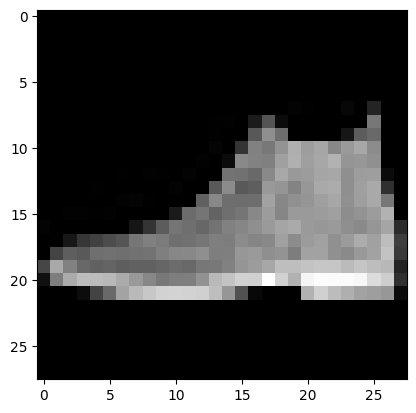

In [16]:
test_dataset = FashionMNIST(root = 'data/', train = False, transform = transforms.ToTensor())
print("Length of Test Datasets: ", len(test_dataset))
img, label = test_dataset[0]
plt.imshow(img[0], cmap = 'gray')
print("Shape: ", img.shape)
print('Label: ', label)

In [17]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _, preds = torch.max(yb, dim = 1)
    return(preds[0].item())

In [18]:
img, label = test_dataset[0]
print('Label:', label, ', Predicted :', predict_image(img, model))

Label: 9 , Predicted : 9


In [19]:
test_loader = DataLoader(test_dataset, batch_size = 256, shuffle = False)
result = evaluate(model, test_loader)
result

{'val_loss': 0.8984165191650391, 'val_acc': 0.7132812738418579}

In [20]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        output = self.out(x)
        return output, x

cnn = CNN()
print(cnn)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


In [21]:
loss_func = nn.CrossEntropyLoss()
loss_func

optimizer = optim.Adam(cnn.parameters(), lr = 0.01)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

In [22]:
from torch.autograd import Variable

def train(num_epochs, cnn, loaders):
    cnn.train()
    optimizer = optim.Adam(cnn.parameters(), lr = 0.01)
    loss_func = nn.CrossEntropyLoss()
    total_step = len(loaders)

    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders):

            b_x = Variable(images)
            b_y = Variable(labels)
            output = cnn(b_x)[0]
            loss = loss_func(output, b_y)

            optimizer.zero_grad()

            loss.backward()
            optimizer.step()

            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
                pass
        pass
    pass

In [23]:
cnn = CNN()
cnn.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in train_loader:
        test_output, last_layer = cnn(images)
        pred_y = torch.max(test_output, 1)[1].data.squeeze()
        accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
        pass
print('Accuracy of the model on the 10000 test images: %.2f' % accuracy)


Accuracy of the model on the 10000 test images: 0.06


In [24]:
train(num_epochs=5, cnn=cnn, loaders=train_loader)

Epoch [1/5], Step [100/391], Loss: 0.5403
Epoch [1/5], Step [200/391], Loss: 0.2524
Epoch [1/5], Step [300/391], Loss: 0.3139
Epoch [2/5], Step [100/391], Loss: 0.2870
Epoch [2/5], Step [200/391], Loss: 0.2485
Epoch [2/5], Step [300/391], Loss: 0.4359
Epoch [3/5], Step [100/391], Loss: 0.1902
Epoch [3/5], Step [200/391], Loss: 0.2879
Epoch [3/5], Step [300/391], Loss: 0.4638
Epoch [4/5], Step [100/391], Loss: 0.2663
Epoch [4/5], Step [200/391], Loss: 0.2498
Epoch [4/5], Step [300/391], Loss: 0.2585
Epoch [5/5], Step [100/391], Loss: 0.2008
Epoch [5/5], Step [200/391], Loss: 0.2398
Epoch [5/5], Step [300/391], Loss: 0.3076


In [25]:
cnn.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in train_loader:
        test_output, last_layer = cnn(images)
        pred_y = torch.max(test_output, 1)[1].data.squeeze()
        accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
        pass
print('Test Accuracy of the model on the 10000 test images: %.2f' % accuracy)


Test Accuracy of the model on the 10000 test images: 0.91


In [26]:
cnn.train(mode=False)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        test_output, last_layer = cnn(images)
        pred_y = torch.max(test_output, 1)[1].data.squeeze()
        accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
        pass
print('Test Accuracy of the model on the 10000 test images: %.2f' % accuracy)


Test Accuracy of the model on the 10000 test images: 0.88


In [27]:
sample = next(iter(test_loader))
imgs, lbls = sample

actual_thing = lbls[:10].numpy()
actual_thing

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_thing}')

Prediction number: [9 2 1 1 0 1 4 6 5 7]
Actual number: [9 2 1 1 6 1 4 6 5 7]


# HW 2 - Experiment with different numbers of layers, size of layers, number of filters, size of filters

In [28]:
import torch.nn as nn

class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 3 * 3, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        features = self.dropout(x)
        output = self.fc(features)
        return output, features

cnn = ImprovedCNN()
print(cnn)


ImprovedCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=1152, out_features=10, bias=True)
)


In [29]:
from torch.autograd import Variable

def train(num_epochs, cnn, loaders):
    cnn.train()
    optimizer = optim.Adam(cnn.parameters(), lr = 0.01)
    loss_func = nn.CrossEntropyLoss()
    total_step = len(loaders)

    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders):

            b_x = Variable(images)
            b_y = Variable(labels)
            output = cnn(b_x)[0]
            loss = loss_func(output, b_y)

            optimizer.zero_grad()

            loss.backward()
            optimizer.step()

            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
                pass
        pass
    pass

In [30]:
cnn = ImprovedCNN()

cnn.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in train_loader:
        test_output, last_layer = cnn(images)
        pred_y = torch.max(test_output, 1)[1].data.squeeze()
        accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
        pass
print('Accuracy of the model on the 10000 test images: %.2f' % accuracy)


Accuracy of the model on the 10000 test images: 0.17


In [31]:
train(num_epochs=5, cnn=cnn, loaders=train_loader)

Epoch [1/5], Step [100/391], Loss: 0.5925
Epoch [1/5], Step [200/391], Loss: 0.5314
Epoch [1/5], Step [300/391], Loss: 0.5078
Epoch [2/5], Step [100/391], Loss: 0.3482
Epoch [2/5], Step [200/391], Loss: 0.2724
Epoch [2/5], Step [300/391], Loss: 0.2609
Epoch [3/5], Step [100/391], Loss: 0.3352
Epoch [3/5], Step [200/391], Loss: 0.4084
Epoch [3/5], Step [300/391], Loss: 0.3526
Epoch [4/5], Step [100/391], Loss: 0.3802
Epoch [4/5], Step [200/391], Loss: 0.1567
Epoch [4/5], Step [300/391], Loss: 0.2920
Epoch [5/5], Step [100/391], Loss: 0.2959
Epoch [5/5], Step [200/391], Loss: 0.2358
Epoch [5/5], Step [300/391], Loss: 0.2165


In [32]:
# Test the model, after the training
cnn.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in train_loader:
        test_output, last_layer = cnn(images)
        pred_y = torch.max(test_output, 1)[1].data.squeeze()
        accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
        pass
print('Test Accuracy of the model on the 10000 test images: %.2f' % accuracy)


Test Accuracy of the model on the 10000 test images: 0.93


In [33]:
sample = next(iter(test_loader))
imgs, lbls = sample

actual_number = lbls[:10].numpy()
actual_number

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')

Prediction number: [9 2 1 1 6 1 4 6 5 7]
Actual number: [9 2 1 1 6 1 4 6 5 7]


In [34]:
%%shell
jupyter nbconvert --to html /content/Homework_Szkop_Julia.ipynb

[NbConvertApp] Converting notebook /content/Homework_Szkop_Julia.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 520154 bytes to /content/Homework_Szkop_Julia.html
